In [1]:
from IPython.display import Image

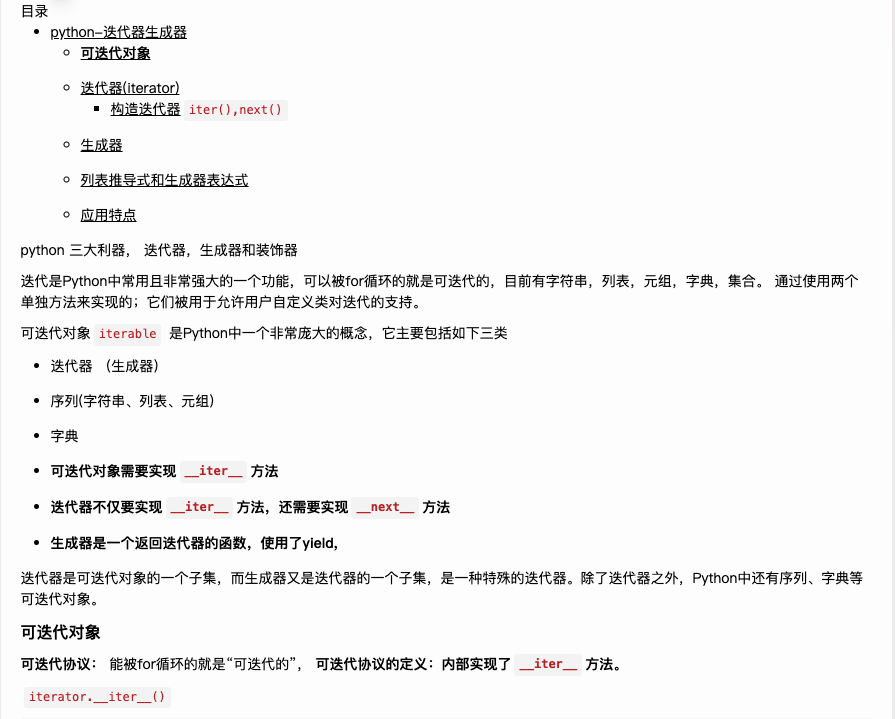

In [2]:
Image(filename='../Image/iter_1.png')

In [3]:
alist=[1,2]
print(alist.__iter__())
#<list_iterator object at 0x1024784a8>


返回迭代器对象本身。 如 range(),str,list,tuple,dict,set

## 迭代器(iterator)


In [4]:
l = [1,2,3]
l_iter = l.__iter__()

item = l_iter.__next__()
print(item)
item = l_iter.__next__()
print(item)
item = l_iter.__next__()
print(item)
item = l_iter.__next__()



1
2
3


StopIteration: 

迭代器遵循迭代器协议：必须拥有__iter__方法和__next__方法。

如 iter(range()),iter(str),iter(list),iter(tuple),iter(dict),iter(set)

迭代器是可迭代对象的一个子集，它是一个可以记住遍历的位置的对象，它与列表、元组、集合、字符串这些可迭代对象的区别就在于next方法的实现，其他列表、元组、集合、字符串这些可迭代对象可以很简单的转化成迭代器，通过Python内置的iter函数能够轻松把可迭代对象转化为迭代器

构造迭代器iter(),next()


In [6]:
# 内置函数**iter()** 函数用来生成迭代器

# iter(object[, sentinel])
'''输入参数
object   -- 支持迭代的集合对象， 可迭代对象
sentinel -- 如果传递了第二个参数，则参数 object 必须是一个可调用的对象
'''
x_List = [1,2,3,4,5]
y_list=iter(x_List)
print(type(x_List))     # <class 'list'>
print(type(y_list))     # <class 'list_iterator'>

print(y_list)
print(next(y_list))    # <list_iterator object at 0x0000016A17F231F0>
print(next(y_list))    #  1 
print(next(y_list))    #  2

# 通过iter函数把list转化成了迭代器
# 迭代器能够记住遍历位置，能够通过next方法不断从前往后访问


# 自定义类

# 循环生成器
class MyNumbers:
    def __iter__(self):
        self.seplist = ["A", "B", "C", "D"]
        self.len = len(self.seplist)
        self.res = self.seplist[0]
        self.i = 0
        return self

    def __next__(self):
        remain = self.i % self.len
        self.i += 1
        self.res = self.seplist[remain]
        return self.res

myclass = MyNumbers()
print(myclass)
myiter = iter(myclass)

print(next(myiter))


<class 'list'>
<class 'list_iterator'>
1
2
3
A


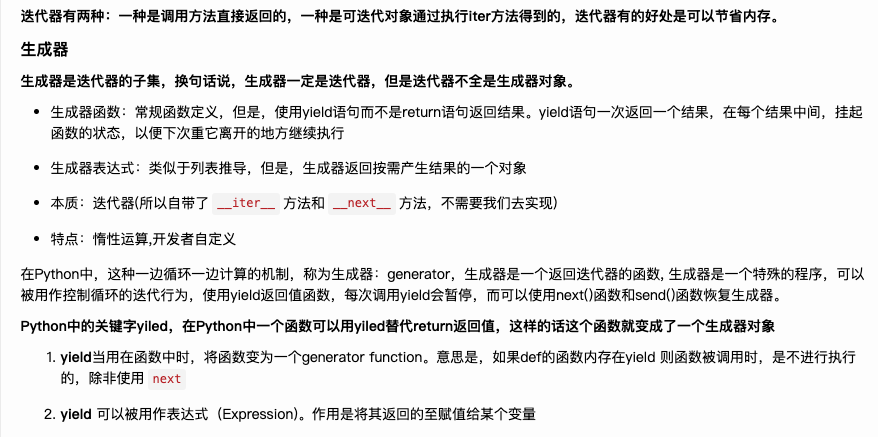

In [7]:
Image(filename='../Image/iter_2.png')

In [ ]:
def generator(array):
    for i in array:
        return i
    
gen = generator([1,2,3,4,5])
print(type(gen))
# 输出
<class 'int'>


In [ ]:
def fun_generator(array):
    for i in array:
        yield(i)
        
gen = fun_generator([1,2,3,4,5])
print(type(gen))

# 输出  调用一个生成器函数，返回的是一个迭代器对象。
<class 'generator'>   


In [8]:
# 实例使用 yield 实现斐波那契数列

def fib(max):
    n,a,b =0,0,1
    while n < max:
        yield b
        a,b =b,a+b
        n = n+1
    return 
 
a = fib(10)

print(fib(10))
print(a.__next__())
print(a.__next__())
print(a.__next__())
print("可以顺便干其他事情")
print(a.__next__())
print(a.__next__())


for b in a:
    print(b)


<generator object fib at 0x107fa7ed0>
1
1
2
可以顺便干其他事情
3
5
8
13
21
34
55


## 列表推导式和生成器表达式

In [ ]:
X = [1, 2, 3, 4, 5]
it = [i for i in X]
gen = (i for i in X)
print(type(X))
print(type(it))
print(type(gen))

# 输出
<class 'list'>
<class 'list'>
<class 'generator'>

# 使用中括号的叫做列表生成式， 惰性计算，延迟求值
# 获得的返回值是一个列表，而使用小括号叫做生成器表达式，获得的返回结果是一个生成器
gen = (i for i in X)
for i in gen:
    print(i)
# 输出
1
2
3
4
5


## 应用特点
对于大数据量处理，将会非常有用。

In [ ]:
#列表解析
total_1 = sum([i for i in range(100000000)])	#内存占用大,机器容易卡死
 
#生成器表达式
total_2 = sum(i for i in range(100000000))	#几乎不占内存

print(total_1,total_2)

# 迭代器在编码方面更加简洁，这是显而易见的，其次生成器运行速度更快，最后一点，也是需要着重说明的一点：节省内存.

### 4G 内存处理 10G 大小的文件

In [ ]:
# 方法1
# 仅使用 Python 内置模板，逐行读取到内存。
# 使用 yield，好处是解耦读取操作和处理操作：

def python_read(filename):
    with open(filename,'r',encoding='utf-8') as f:
        while True:
            line = f.readline()
            if not line:
                return
            yield line
            
if __name__ == '__main__':
    g = python_read('./data/movies.dat')
    for c in g:
        print(c)
        # process c

方法一有缺点，逐行读入，频繁的 IO 操作拖累处理效率。

# 方法2
# 使用pandas  包 read_csv 函数，参数有 38 个之多，功能非常强大
def pandas_read(filename,sep=',',chunksize=5):
    reader = pd.read_csv(filename,sep,chunksize=chunksize)
    while True:
        try:
            yield reader.get_chunk()
        except StopIteration:
            print('---Done---')
            break
            
使用如同方法一：

if __name__ == '__main__':
    g = pandas_read('./data/movies.dat',sep="::")
    for c in g:
        print(c)
        # process c

